In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
#import scienceplots
import uncertainties as unc
from uncertainties import unumpy as unp
from uncertainties import umath

import os
import utils as uts

from main_data_processor import Data
# plt.rcParams['text.usetex'] = False
#plt.style.use('science')

In [2]:
def plot_each_peg(dat, x_col, y_col, **kwargs):

    for crowder in dat['crowder'].unique():

        df = dat[dat['crowder'] == crowder]

        x = df[x_col]
        y = df[y_col]

        if x.dtype == unc.core.AffineScalarFunc:
            x = unp.nominal_values(x)

        if y.dtype == unc.core.AffineScalarFunc:
            y_nom = unp.nominal_values(y)
            y_err = unp.std_devs(y)


            plt.errorbar(x, y_nom, yerr=y_err, fmt='o', label=crowder, **kwargs)

        else:
            plt.plot(x, y, 'o', label=crowder)

    plt.legend()
    plt.xlabel(x_col)
    plt.ylabel(y_col)

In [3]:
equillibrium_constans_path = 'source_data/MacromoleculeEquilibria_Crowding'
complexation_data_path = 'source_data/IonCrowderComplexation/raw_data'
sodium_path = 'source_data/IonStrengthDependency/Na+_FRET.csv'



all_data =  Data(equillibrium_constans_path, complexation_data_path,sodium_path)

complexation_data = all_data.EquillbriumConstantsObj
equillibrium_constants = all_data.SodiumCrowderComplexationObj

# Sodium crowder complexation

In [4]:
# diffusion coefficient of the Na+ in ultra-pure water
equillibrium_constants.D_Na0

1425.622636

In [5]:
df = equillibrium_constants.analyzed_data

df

,wt_%,D_Na_[um2/s],D_Na_err_[um2/s],D_crowder_[um2/s],D_crowder_err_[um2/s],crowder,D_Na_uf_[um2/s],D_crowder_uf_[um2/s],MW_[g/mol],No_mono,...,mass concentration [g/cm3],concentration [M],monomers concentration [M],ksi,Reff,D_Na_[um2/s] corr,n Beta [1/M],chi2,redchi2,R^2
0,1.0,1365.0760,37.30372,30.83452,0.055466,PEG35000,(1.37+/-0.04)e+03,30.83+/-0.06,35000.0,794.142565,...,0.009987,0.000285,0.226613,13.490967,0.172038,1416.671547,173+/-10,10.591181,1.323898,0.912592
1,1.5,1404.5150,45.17060,26.34168,0.040308,PEG35000,(1.40+/-0.05)e+03,26.34+/-0.04,35000.0,794.142565,...,0.014994,0.000428,0.340216,9.946959,0.172038,1412.380653,173+/-10,10.591181,1.323898,0.912592
2,3.0,1237.3990,35.69728,18.37717,0.025882,PEG35000,(1.24+/-0.04)e+03,18.377+/-0.026,35000.0,794.142565,...,0.030067,0.000859,0.682213,5.902915,0.172038,1399.778853,173+/-10,10.591181,1.323898,0.912592
3,4.5,1289.8420,62.48437,13.03956,0.061334,PEG35000,(1.29+/-0.06)e+03,13.04+/-0.06,35000.0,794.142565,...,0.045218,0.001292,1.025991,4.346593,0.172038,1387.436659,173+/-10,10.591181,1.323898,0.912592
4,6.0,1126.2400,58.74440,10.01745,0.025307,PEG35000,(1.13+/-0.06)e+03,10.017+/-0.025,35000.0,794.142565,...,0.060448,0.001727,1.371549,3.496214,0.172038,1375.275703,173+/-10,10.591181,1.323898,0.912592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,7.5,1059.3110,56.60522,146.77290,0.459099,PEG1500,(1.06+/-0.06)e+03,146.8+/-0.5,1500.0,33.643133,...,0.075756,0.050504,1.699114,2.760586,0.169324,1359.115805,7.4+/-0.6,4.987585,0.712512,0.949513
85,10.0,1031.9890,160.91470,132.50240,0.334128,PEG1500,(1.03+/-0.16)e+03,132.50+/-0.33,1500.0,33.643133,...,0.101444,0.067629,2.275265,2.217656,0.169324,1338.084111,7.4+/-0.6,4.987585,0.712512,0.949513
86,12.5,920.6009,104.00470,113.96290,0.233071,PEG1500,(9.2+/-1.0)e+02,113.96+/-0.23,1500.0,33.643133,...,0.127350,0.084900,2.856305,1.869884,0.169324,1317.375825,7.4+/-0.6,4.987585,0.712512,0.949513
87,15.0,831.2803,58.79731,104.98180,0.135397,PEG1500,(8.3+/-0.6)e+02,104.98+/-0.14,1500.0,33.643133,...,0.153474,0.102316,3.442236,1.625690,0.169324,1296.953657,7.4+/-0.6,4.987585,0.712512,0.949513


/tmp/ipykernel_34459/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_34459/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


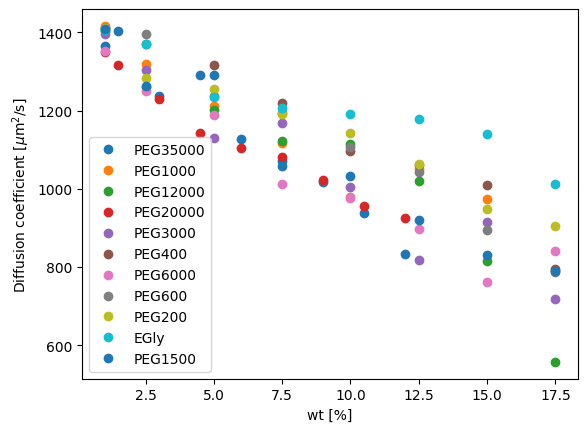

In [8]:
plot_each_peg(df, 'wt_%', 'D_Na_[um2/s]')
plt.xlabel('wt [%]')
plt.ylabel(r'Diffusion coefficient [$\mu$m$^2$/s]')
plt.savefig('./plots/plots_for_publication/sodium_in_PEGs.png', dpi=600)
plt.legend()

### Nanosiscosity effects

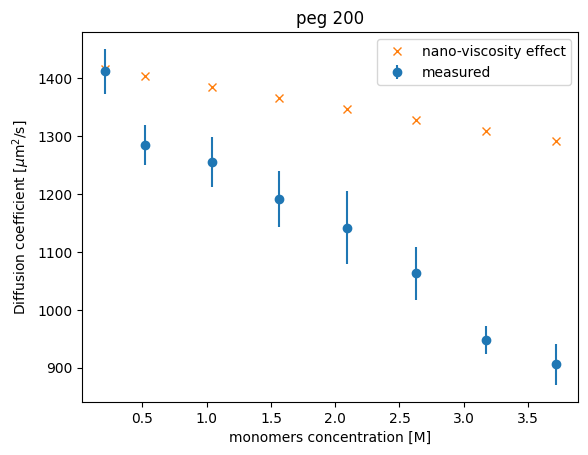

In [14]:
peg200 = df[df['crowder'] == 'PEG200']


D_measured, D_measured_err = uts.get_float_uncertainty(peg200['D_Na_uf_[um2/s]'])

D_viscosity = peg200['D_Na_[um2/s] corr']


plt.errorbar( peg200['monomers concentration [M]'] , D_measured, yerr=D_measured_err, fmt='o', label='measured')
plt.plot( peg200['monomers concentration [M]'] , D_viscosity, 'x',  label='nano-viscosity effect')
plt.title('peg 200')
plt.xlabel('monomers concentration [M]')
plt.ylabel(r'Diffusion coefficient [$\mu$m$^2$/s]')
plt.legend()
plt.savefig('./plots/plots_for_publication/nanoviscosity_effect.png', dpi=600)

# nBeta as a function of monomer number

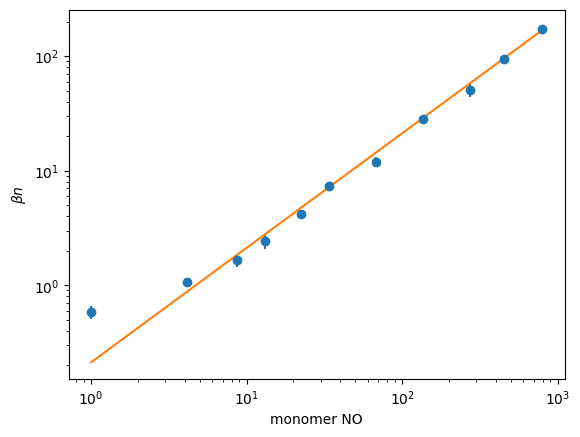

In [10]:
x = df['No_mono'].unique()
y, y_err = uts.get_float_uncertainty(df['n Beta [1/M]'].unique())

a = np.dot(x, y) / np.dot(x, x)

x_int = np.linspace(min(x), max(x))

plt.errorbar(x, y, y_err, fmt='o', label='experimental')
plt.plot(x_int, a * x_int)
plt.xlabel('monomer NO')
plt.ylabel(r'$\beta n$')
plt.xscale('log')
plt.yscale('log')
plt.savefig('./plots/plots_for_publication/Bn_mon_NO.png', dpi=600)

# Ion concentration dependency 

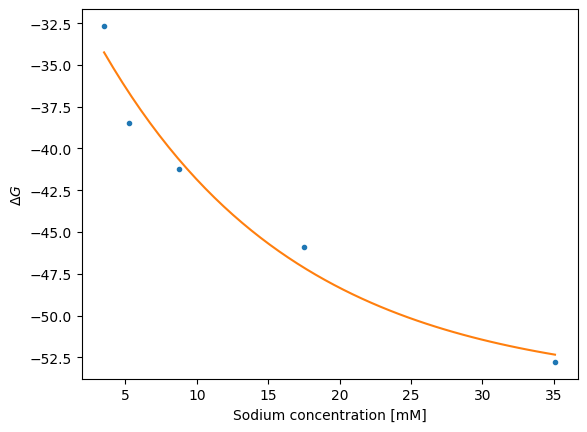

In [130]:
ion_df = all_data.SodiumDependencyObj

conc = ion_df.raw_data['C_Na+_[mM]']
conc_fit = np.linspace(conc.min(), conc.max())

popt = ion_df.popt_eff


plt.plot(conc, ion_df.raw_data['dG_[kJ/mol]'], '.')
plt.plot(conc_fit, ion_df.model(conc_fit, *popt))
plt.xlabel('Sodium concentration [mM]')
plt.ylabel(r'$\Delta G$')
plt.savefig('plots/plots_for_publication/sodium_dependency.png', dpi=600)

# Gibbs Free Energy

In [11]:
data = all_data.data

data.columns

Index(['crowder', 'crowder wt. [%]', 'sample', 'charge 1', 'charge 2',
       'Rg 1 [nm]', 'Rg 2 [nm]', 'T [K]', 'Na conc. [mM]', 'I [mM]',
       'molar mass [g/mol]', 'source', 'K_uf [M]', 'density', 'MW_[g/mol]',
       'No_mono', 'Rg_[nm]', 'Rg_err_[nm]', 'Rh_[nm]', 'Rh_err_[nm]',
       'V_Rg_[nm3]', 'V_Rg_err_[nm3]', 'c*_[g/cm3]', 'concentration [M]',
       'mass_concentration_[g/mL]', 'c*_[M]', 'c/c*', 'a2_exp', 'a1_exp',
       'a0_exp', 'chi2', 'chi2_red', 'R2', 'nBeta_[1/M]', 'Na_free_[mM]',
       'dG_Na_[kJ/mol]', 'dG_exp_[kJ/mol]', 'dG_depl_dil_[kJ/mol]',
       'dG_depl_semi_dil_[kJ/mol]'],
      dtype='object')

In [12]:
data['a2_exp'] * data['concentration [M]'] ** 2

0            -0.0+/-0
1      -0.086+/-0.019
2        -0.19+/-0.04
3        -0.35+/-0.08
4        -0.55+/-0.12
            ...      
114      -0.91+/-0.25
115        -1.6+/-0.5
116        -2.6+/-0.7
117        -3.8+/-1.1
118        -7.0+/-1.9
Length: 119, dtype: object

In [13]:
# Removing the 50% concentration
data = data[data['crowder wt. [%]'] < 50]

/tmp/ipykernel_34459/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_34459/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


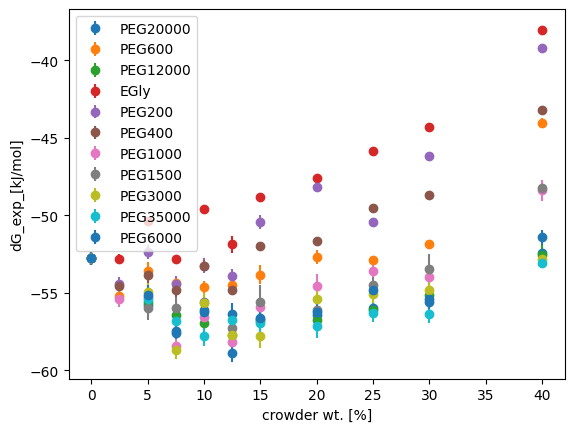

In [14]:
plot_each_peg(data, 'crowder wt. [%]', 'dG_exp_[kJ/mol]')
plt.savefig('./plots/plots_for_publication/deltaG_experimental.png', dpi=600)

# Minima of the Delta G

In [17]:
data['deltaG_minima'] = -data['a1_exp']/(2 * data['a2_exp']) /data['c*_[M]']

/tmp/ipykernel_34459/1589486482.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['deltaG_minima'] = -data['a1_exp']/(2 * data['a2_exp']) /data['c*_[M]']


/tmp/ipykernel_34459/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_34459/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


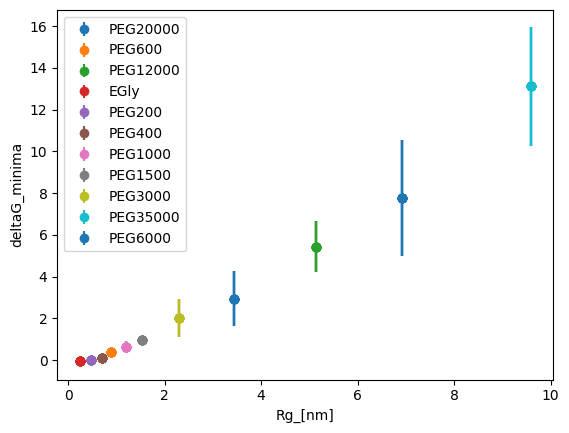

In [132]:
plot_each_peg(data, 'Rg_[nm]', 'deltaG_minima')
plt.savefig('./plots/plots_for_publication/deltaG_minimum.png', dpi=600)

/tmp/ipykernel_34459/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_34459/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


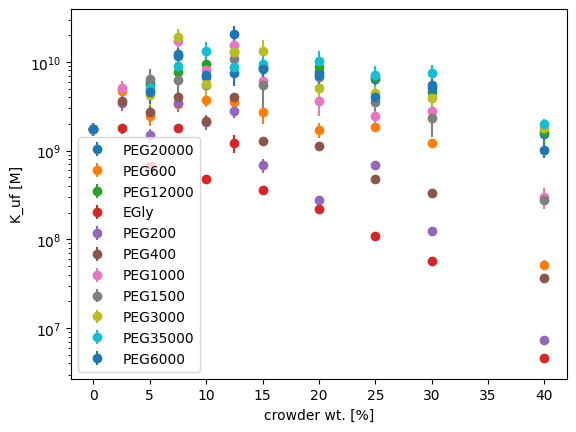

In [15]:
plot_each_peg(data, 'crowder wt. [%]', 'K_uf [M]')
plt.yscale('log')
plt.savefig('./plots/plots_for_publication/K_experimental.png', dpi=600)

/tmp/ipykernel_34459/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_34459/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


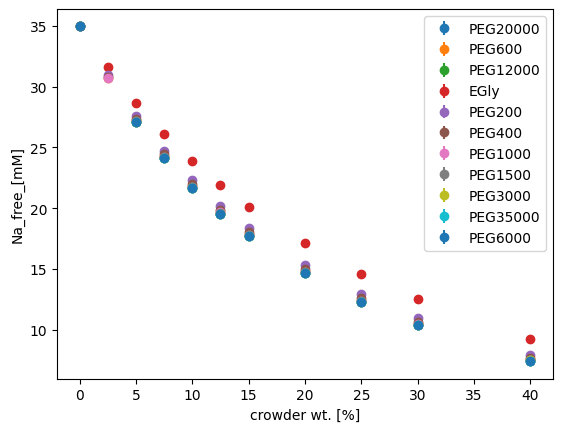

In [128]:
plot_each_peg(data, 'crowder wt. [%]', 'Na_free_[mM]')
plt.savefig('plots/plots_for_publication/free_sodium.png', dpi=600)

/tmp/ipykernel_34459/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_34459/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


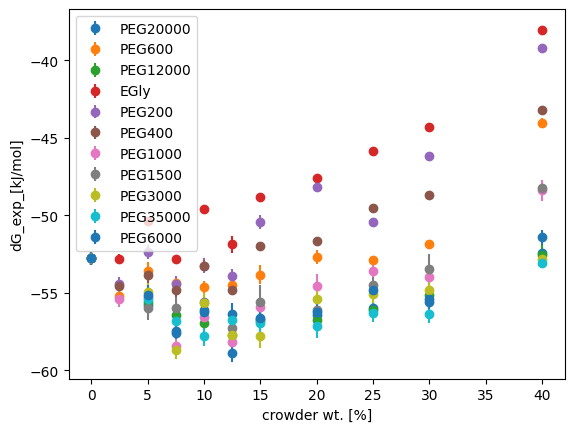

In [95]:
plot_each_peg(data, 'crowder wt. [%]', 'dG_exp_[kJ/mol]')

/tmp/ipykernel_34459/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_34459/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


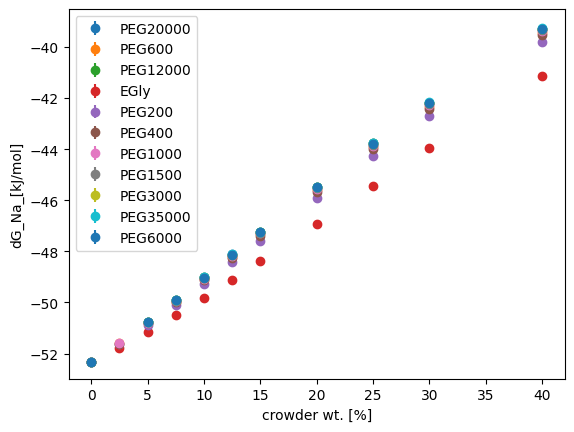

In [29]:
plot_each_peg(data, 'crowder wt. [%]', 'dG_Na_[kJ/mol]')
plt.savefig('plots/plots_for_publication/impact_of_sodium_to_reaction.png', dpi=600)

/tmp/ipykernel_34459/1051262290.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['rest_dG_[kJ/mol]'] = data['dG_exp_[kJ/mol]'] - data['dG_Na_[kJ/mol]']
/tmp/ipykernel_34459/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_34459/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


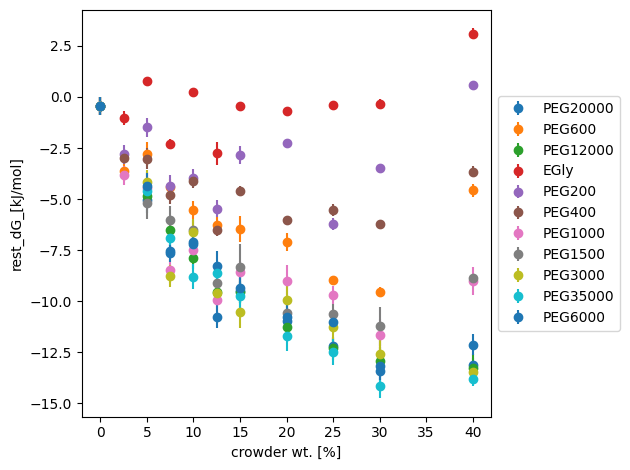

In [129]:
data['rest_dG_[kJ/mol]'] = data['dG_exp_[kJ/mol]'] - data['dG_Na_[kJ/mol]']

plot_each_peg(data, 'crowder wt. [%]', 'rest_dG_[kJ/mol]')

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.plot()
plt.tight_layout()
plt.savefig('plots/plots_for_publication/rest_dG.png', dpi=600)

In [105]:
df = data[(data['molar mass [g/mol]'] >= 3000) & (data['concentration [M]'] > 0)]

In [106]:
df['test'] = -df['rest_dG_[kJ/mol]'] / df['concentration [M]'] ** (9/4)

/tmp/ipykernel_34459/558756207.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['test'] = -df['rest_dG_[kJ/mol]'] / df['concentration [M]'] ** (9/4)


In [107]:
V = 0.825 # ml/g
alpha = 0.49

In [108]:
df['c*N_[ml/g]'] = df['No_mono'] ** (-4/5) / V

/tmp/ipykernel_34459/2983781308.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['c*N_[ml/g]'] = df['No_mono'] ** (-4/5) / V


In [109]:
df['x'] = df['mass_concentration_[g/mL]']/df['c*N_[ml/g]']

/tmp/ipykernel_34459/1080301181.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['x'] = df['mass_concentration_[g/mL]']/df['c*N_[ml/g]']


In [110]:
df['log(x)'] = np.log10(df['x'])

/tmp/ipykernel_34459/81471199.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['log(x)'] = np.log10(df['x'])


In [111]:
df['y'] = np.log10(8.314 * 293.15/(44 * V) * (df['x'] + alpha * (df['x'])**(9/4)) * 10 ** 7)

/tmp/ipykernel_34459/3035980245.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['y'] = np.log10(8.314 * 293.15/(44 * V) * (df['x'] + alpha * (df['x'])**(9/4)) * 10 ** 7)


/tmp/ipykernel_34459/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_34459/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


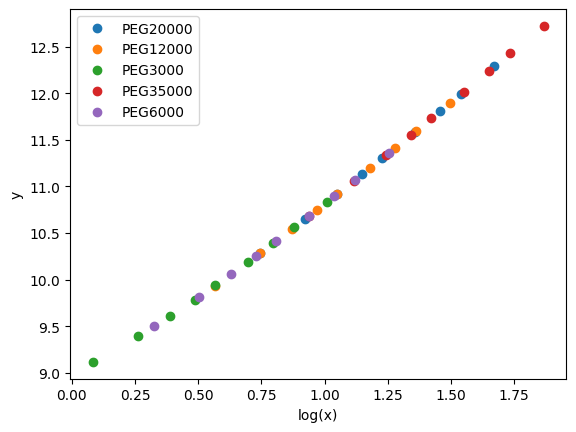

In [113]:
plot_each_peg(df, 'log(x)' ,'y')

# Literature

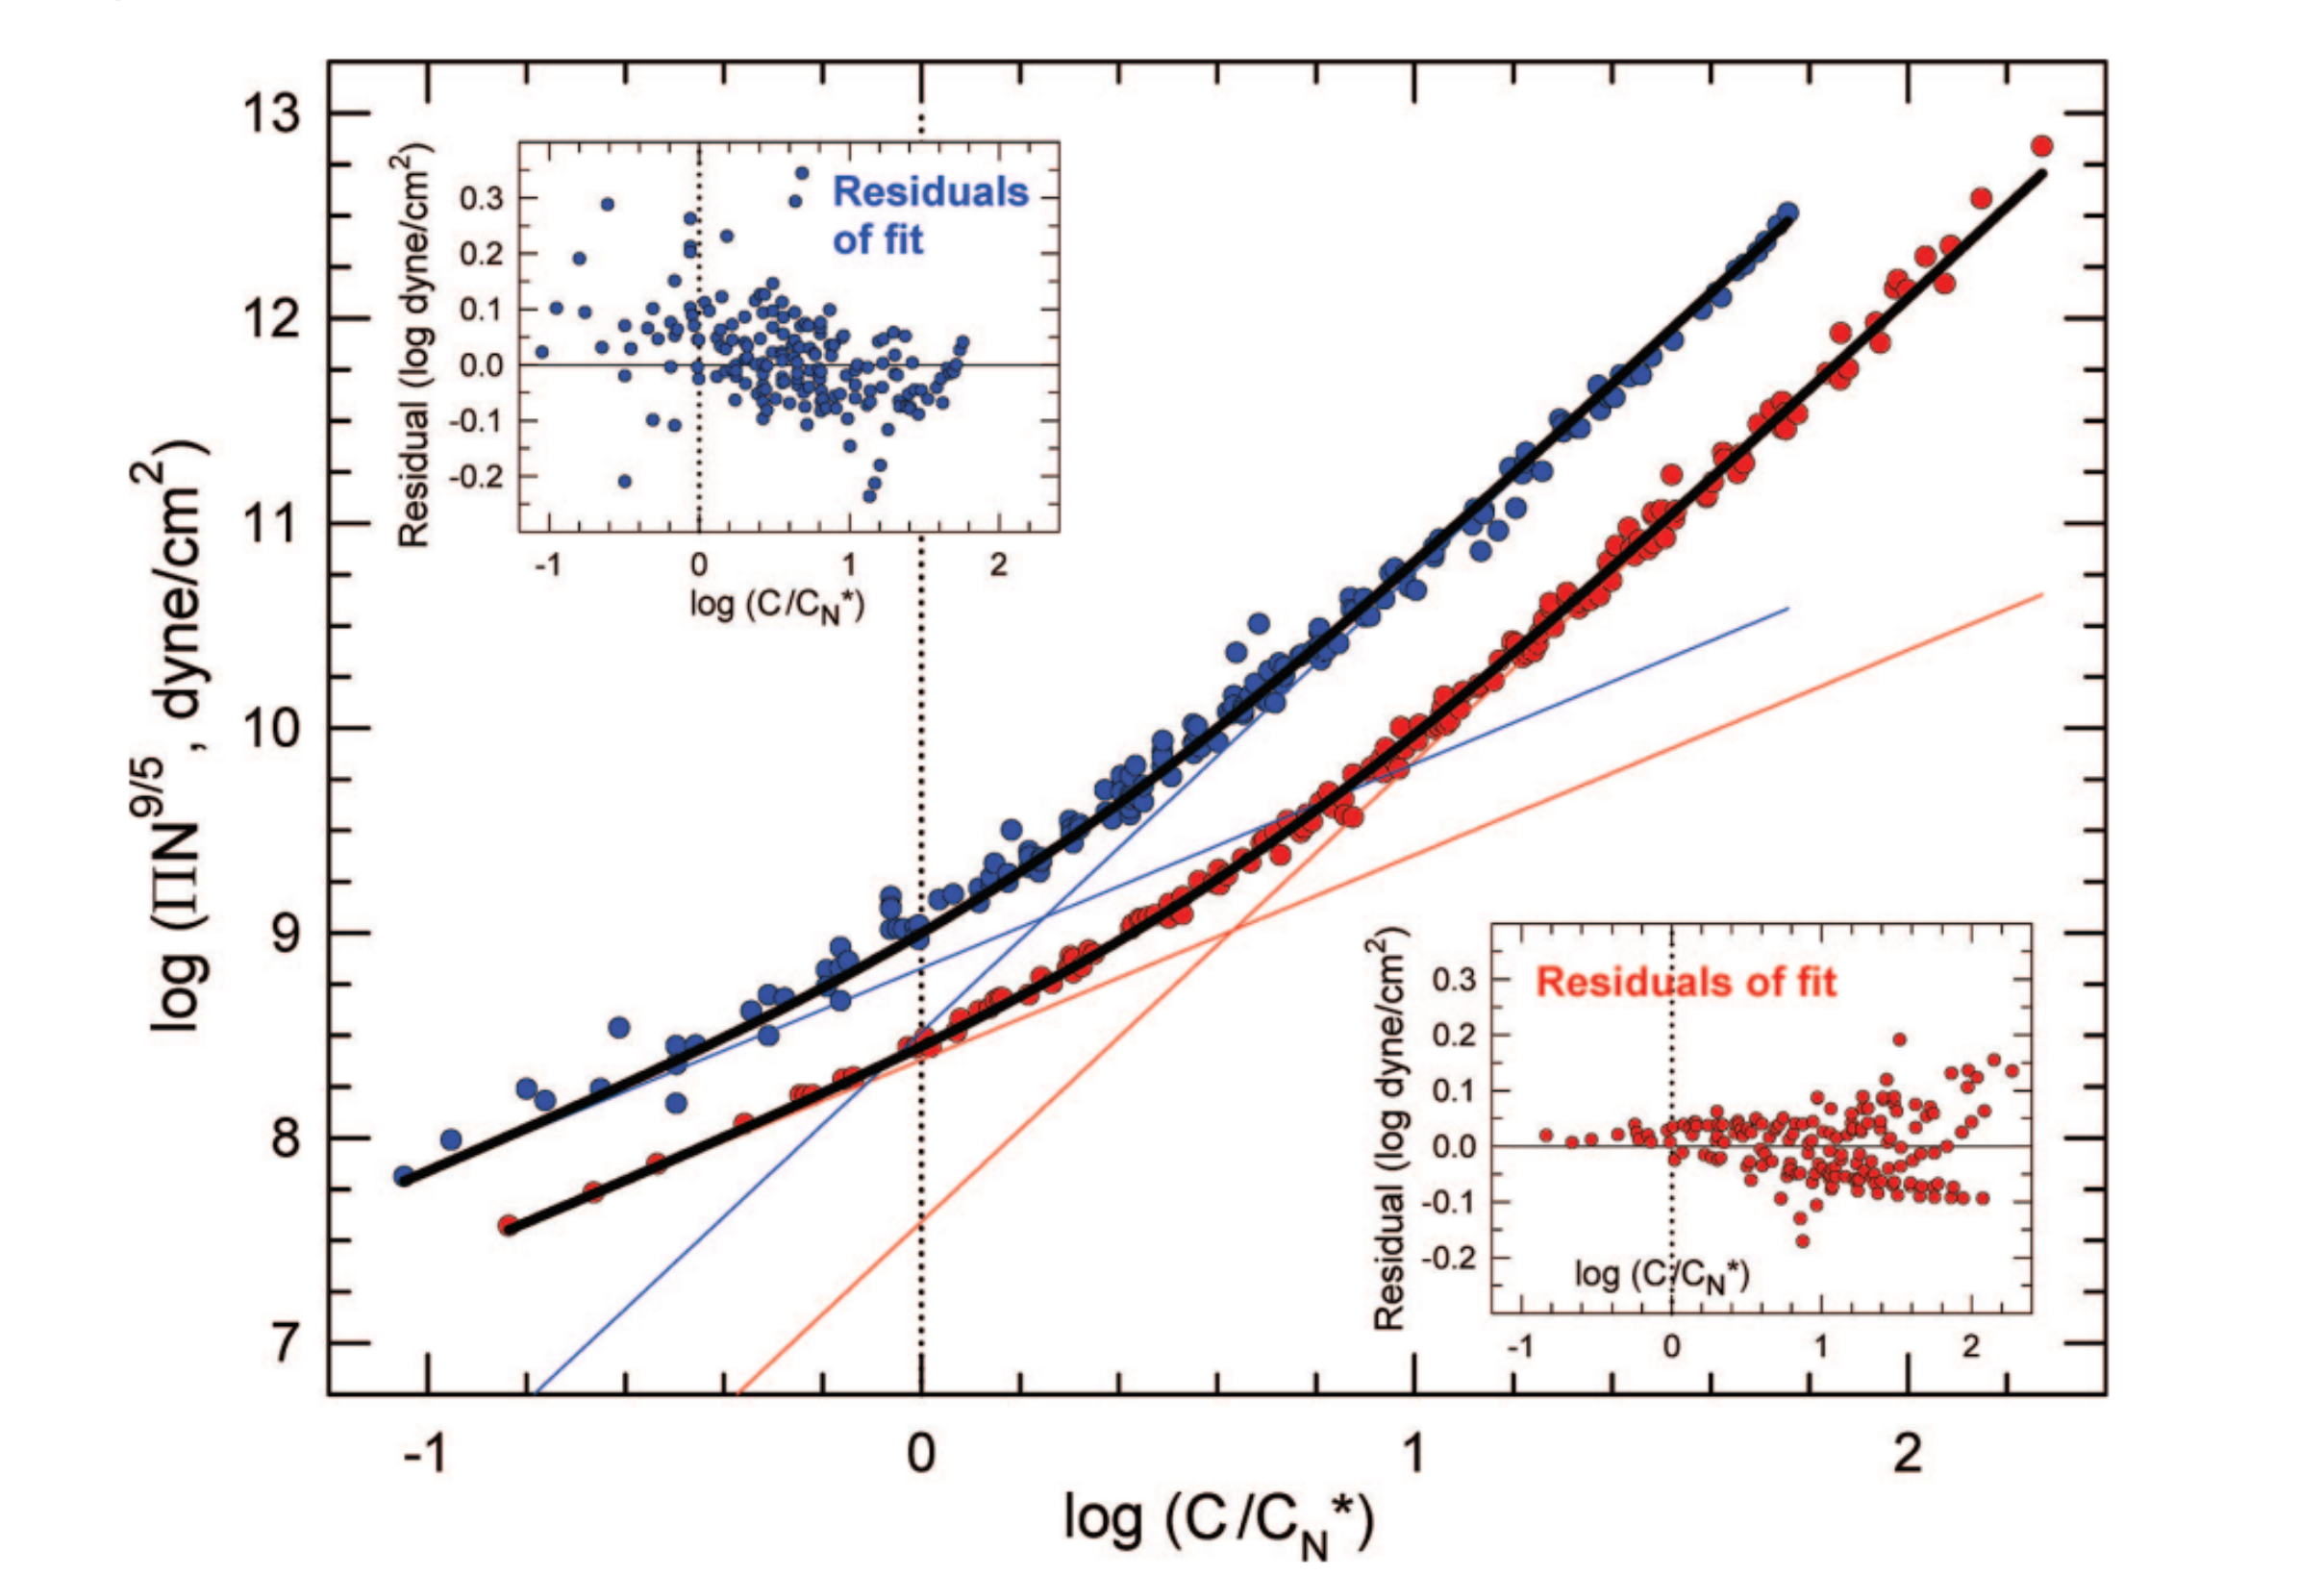

In [114]:
df['pi_[Pa]'] = 8.314 * 298.15/(44 * V) * (df['x'] + alpha * (df['x'])**(9/4)) / df['No_mono'] ** (9/5) * 10 ** 6

/tmp/ipykernel_34459/3148064446.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pi_[Pa]'] = 8.314 * 298.15/(44 * V) * (df['x'] + alpha * (df['x'])**(9/4)) / df['No_mono'] ** (9/5) * 10 ** 6


/tmp/ipykernel_34459/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_34459/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


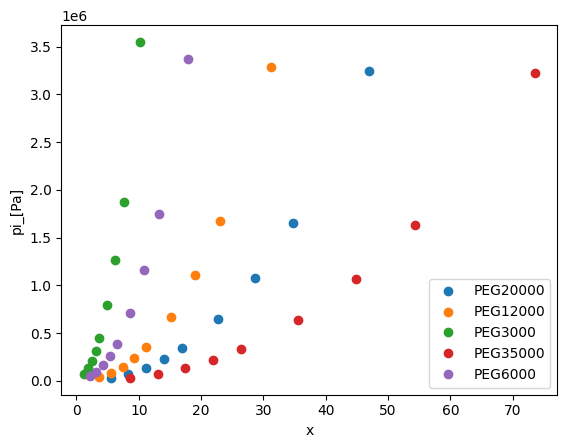

In [115]:
plot_each_peg(df, 'x', 'pi_[Pa]')

In [116]:
df['dG_rest/pi_[m3/mol]'] = -df['rest_dG_[kJ/mol]'] * 1000/df['pi_[Pa]']

/tmp/ipykernel_34459/4177060825.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dG_rest/pi_[m3/mol]'] = -df['rest_dG_[kJ/mol]'] * 1000/df['pi_[Pa]']


/tmp/ipykernel_34459/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_34459/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


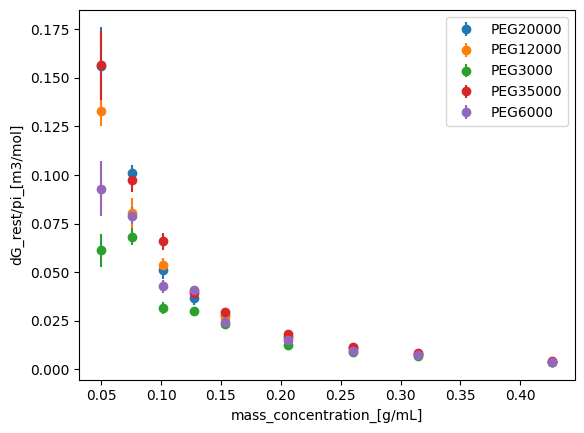

In [117]:
plot_each_peg(df, 'mass_concentration_[g/mL]', 'dG_rest/pi_[m3/mol]')

In [118]:
df['Veff_[nm3]'] = df['dG_rest/pi_[m3/mol]'] * 10 ** (27) / (6.02 * 10 ** (23))

/tmp/ipykernel_34459/3949307605.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Veff_[nm3]'] = df['dG_rest/pi_[m3/mol]'] * 10 ** (27) / (6.02 * 10 ** (23))


/tmp/ipykernel_34459/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_34459/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


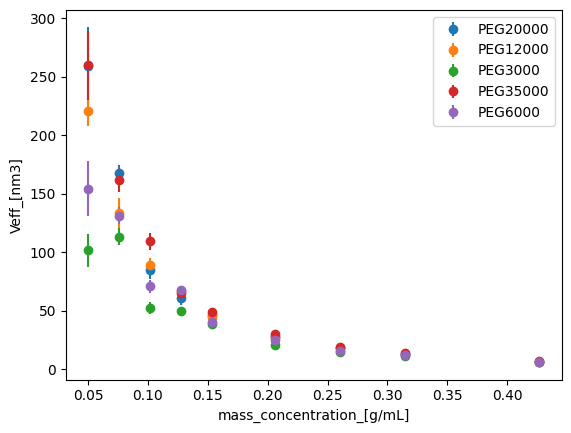

In [120]:
plot_each_peg(df, 'mass_concentration_[g/mL]', 'Veff_[nm3]')


/tmp/ipykernel_34459/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_34459/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


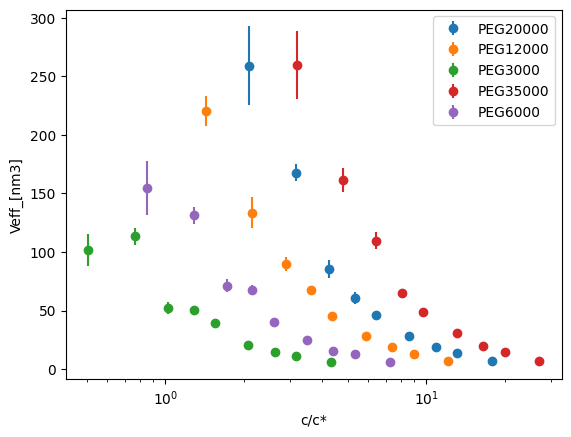

In [127]:
plot_each_peg(df, 'c/c*', 'Veff_[nm3]')
plt.xscale('log')
plt.savefig('plots/plots_for_publication/effective_volume.png')

In [122]:
chosen = df[df['MW_[g/mol]'] > 1500]
chosen['V_eff/(Rg ksi)_[nm]'] = chosen['Veff_[nm3]']/ (chosen['Rg_[nm]'] * chosen['c/c*'] ** (-0.77)) / df['Rg_[nm]']

In [123]:
all_data.DepletionObj.ssDNA_parameters

{'L_contour_nm': 8.19,
 'R_end_to_end_nm': 5.684535795825926,
 'Rg_nm': 2.320702020726569,
 'Cylinder_height_nm': 5.684535795825926,
 'Cylinder_diameter_nm': 4.641404041453138,
 'Cylinder_volume_nm3': 96.17974894675449}

/tmp/ipykernel_34459/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_34459/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


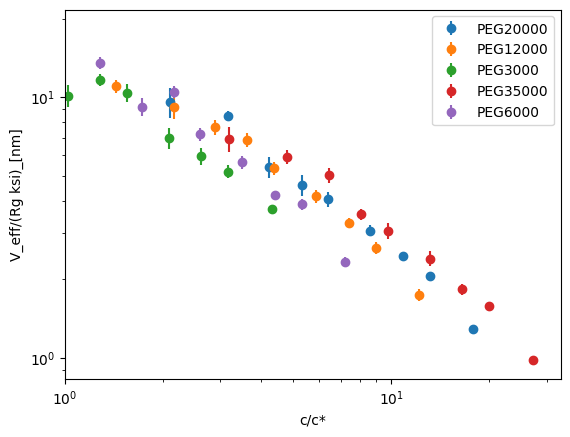

In [126]:
plot_each_peg(chosen, 'c/c*', 'V_eff/(Rg ksi)_[nm]')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1)
plt.savefig('plots/plots_for_publication/depletion_scaling.png', dpi=600)

In [21]:
cp = data[data['c/c*']>1].groupby(by='crowder').min().sort_values('MW_[g/mol]').reset_index()

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'PEG400'),
  Text(1, 0, 'PEG600'),
  Text(2, 0, 'PEG1000'),
  Text(3, 0, 'PEG1500'),
  Text(4, 0, 'PEG3000'),
  Text(5, 0, 'PEG6000'),
  Text(6, 0, 'PEG12000'),
  Text(7, 0, 'PEG20000'),
  Text(8, 0, 'PEG35000')])

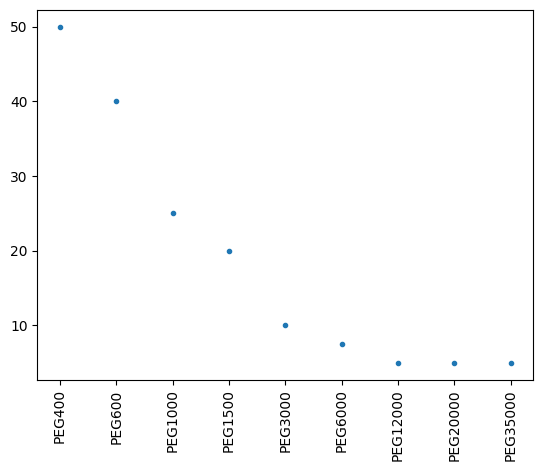

In [22]:
plt.plot(cp['crowder'], cp['crowder wt. [%]'], '.')
plt.xticks(rotation=90)

/tmp/ipykernel_88009/3952683910.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_88009/3952683910.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


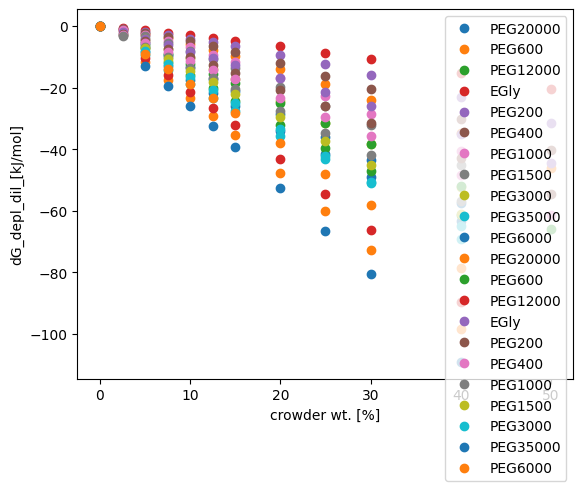

In [25]:
plot_each_peg(data, 'crowder wt. [%]', 'dG_depl_semi_dil_[kJ/mol]', linestyle='-')
plot_each_peg(data, 'crowder wt. [%]', 'dG_depl_dil_[kJ/mol]', linestyle='-')

# Taylor Series expansion of the theoretical model

In [10]:
a

0.21206370326136137

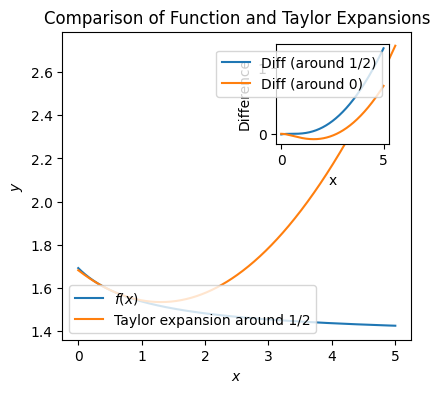

In [11]:
# Define the range for x
x = np.linspace(0, 5, 500)  # Ensure the domain of the function is valid

a = 0.0754 / 0.1754 * 4 + 0.0246 / 0.1754 

Bn = 1

# Define the functions
y1 = np.sqrt(1 /(Bn * x + 1) + a)
# Taylor expansion around x = 1/2
sqrt_term = np.sqrt(2 / 3)
y2 =(4 * a + 2) / (3 * np.sqrt(3) * (3 * a + 2)**(3/2)) * (Bn*x)**2 - (2 * (5 * a + 3)) / (3 * np.sqrt(3) * (3 * a + 2)**(3/2)) * Bn*x + (54 * a**2 + 80 * a + 29) / (6 * np.sqrt(3) * (3 * a + 2)**(3/2))
difference = y2 - y1

# Taylor expansion around x = 0
y3 = np.sqrt(1 + a) - (1 / 2) * (1 + a)**(-1/2) * x + (3 / 8) * (1 + a)**(-3/2) * x**2

# Differences
difference1 = y2 - y1  # Difference for Taylor around 1/2
difference2 = y3 - y1  # Difference for Taylor around 0


fig, ax = plt.subplots(figsize=(4.5, 4))

ax.plot(Bn*x, y1, label=r'$f(x)$')
ax.plot(Bn*x, y2, label='Taylor expansion around 1/2')
#ax.plot(x, y3, label='Taylor expansion around 0')
#ax.plot(x, 5*y4, label='test')
ax.legend(loc='lower left')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.set_title('Comparison of Function and Taylor Expansions')
# Create inset manually
inset_ax = plt.axes([0.6, 0.6, 0.25, 0.25])  # [left, bottom, width, height]
inset_ax.plot(x, difference1, label='Diff (around 1/2)')
inset_ax.plot(x, difference2, label='Diff (around 0)')
inset_ax.set_xlabel('x')
inset_ax.set_ylabel('Difference')
inset_ax.legend()
plt.savefig('function_taylor.pdf', format='pdf', dpi=600)

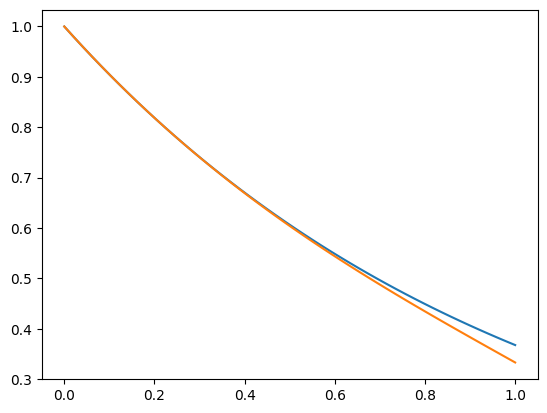

In [12]:
x = np.linspace(0, 1)
y = np.exp(-x)
y_tayl = 1 - x + 1/2 * x** 2 - 1/6 * x**3

plt.plot(x,y)
plt.plot(x, y_tayl)

pandas.core.frame.DataFrame

# Theoretical analysis export

In [3]:
dat = all_data.data
# dat = dat[np.sign(dat['charge 1']) == np.sign(dat['charge 2'])]
# def filter_quadratic_fits(dat):
#     filtering_mask = (dat['chi2_red'] > 0.2) & (dat['chi2_red'] < 10) & (dat['R2'] > 0.5) & (dat['a1_exp'] > 0) & (dat['a2_exp'] < 0)
#     return dat[filtering_mask]

#dat = filter_quadratic_fits(dat)
#dat.sort_values(by=['molar mass [g/mol]', 'concentration [M]'], inplace=True)

In [4]:
df = dat[dat['sample'] == 'ssDNA_13bp']
df['mon_conc_[M]'] = df['No_mono'] * df['concentration [M]']
df.sort_values(by=['molar mass [g/mol]','concentration [M]'], inplace=True)
df.columns

/tmp/ipykernel_26092/3082956360.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['mon_conc_[M]'] = df['No_mono'] * df['concentration [M]']
/tmp/ipykernel_26092/3082956360.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(by=['molar mass [g/mol]','concentration [M]'], inplace=True)


Index(['sample', 'Rg 1 [nm]', 'Rg 2 [nm]', 'charge 1', 'charge 2', 'crowder',
       'molar mass [g/mol]', 'crowder wt. [%]', 'T [K]', 'Na conc. [mM]',
       'I [mM]', 'source', 'K_uf [M]', 'density', 'MW_[g/mol]', 'No_mono',
       'Rg_[nm]', 'Rg_err_[nm]', 'Rh_[nm]', 'Rh_err_[nm]', 'V_Rg_[nm3]',
       'V_Rg_err_[nm3]', 'c*_[g/cm3]', 'concentration [M]', 'c*_[M]', 'c/c*',
       'a2_exp', 'a1_exp', 'a0_exp', 'chi2', 'chi2_red', 'R2', 'n Beta [1/M]',
       'theory_a2', 'theory_a1', 'Delta_G_elec_theory_[J/mol]',
       'Delta_G_depl_theory_[J/mol]', 'r_D_[m3]',
       'simple_overlap_volume_[L/M]', 'Delta_G_simple_depl_theory_[J/mol]',
       'Delta_G_exp_[J/mol]', 'Delta_G0_exp_[J/mol]', 'mon_conc_[M]'],
      dtype='object')

In [5]:
df['No_mono']

58       1.409081
59       1.409081
60       1.409081
61       1.409081
62       1.409081
          ...    
261    794.551646
262    794.551646
263    794.551646
264    794.551646
265    794.551646
Name: No_mono, Length: 119, dtype: float64

In [18]:
old_old = pd.read_csv('old_old_way.csv')
old = pd.read_csv('old_way.csv', sep=',')
new = pd.read_csv('new_way.csv', sep=',')

In [19]:
old_old.columns

Index(['Unnamed: 0', 'sample', 'Rg 1 [nm]', 'Rg 2 [nm]', 'charge 1',
       'charge 2', 'crowder', 'molar mass [g/mol]', 'crowder wt. [%]', 'T [K]',
       'Na conc. [mM]', 'I [mM]', 'source', 'K_uf [M]', 'density',
       'MW_[g/mol]', 'No_mono', 'Rg_[nm]', 'Rg_err_[nm]', 'Rh_[nm]',
       'Rh_err_[nm]', 'V_Rg_[nm3]', 'V_Rg_err_[nm3]', 'c*_[g/cm3]',
       'concentration [M]', 'c*_[M]', 'c/c*', 'a2_exp', 'a1_exp', 'a0_exp',
       'chi2', 'chi2_red', 'R2', 'n Beta [1/M]', 'theory_a2', 'theory_a1',
       'Delta_G_elec_theory_[J/mol]', 'Delta_G_depl_theory_[J/mol]',
       'r_D_[m3]', 'simple_overlap_volume_[L/M]',
       'Delta_G_simple_depl_theory_[J/mol]', 'Delta_G_exp_[J/mol]',
       'Delta_G0_exp_[J/mol]', 'mon_conc_[M]'],
      dtype='object')

In [32]:
old_old.shape

(117, 44)

In [34]:
old.shape

(119, 44)

In [24]:
old_old[old_old['crowder'] == 'PEG35000']['K_uf [M]']

107    (1.76+/-0.31)e+09
108      (5.4+/-1.2)e+09
109    (1.04+/-0.21)e+10
110      (1.6+/-0.5)e+10
111    (1.11+/-0.28)e+10
112      (1.3+/-0.4)e+10
113      (1.6+/-0.6)e+10
114    (1.05+/-0.26)e+10
115    (1.19+/-0.28)e+10
116      (2.6+/-0.4)e+09
Name: K_uf [M], dtype: object

In [25]:
old[old['crowder'] == 'PEG35000']['K_uf [M]']

109    (1.76+/-0.31)e+09
110      (5.4+/-1.2)e+09
111    (1.04+/-0.21)e+10
112      (1.6+/-0.5)e+10
113    (1.11+/-0.28)e+10
114      (1.3+/-0.4)e+10
115      (1.6+/-0.6)e+10
116    (1.05+/-0.26)e+10
117    (1.19+/-0.28)e+10
118      (2.6+/-0.4)e+09
Name: K_uf [M], dtype: object

In [26]:
new[new['crowder'] == 'PEG35000']['K_uf [M]']

109    (1.76+/-0.31)e+09
110      (3.5+/-0.7)e+09
111      (4.4+/-0.8)e+09
112      (5.1+/-1.1)e+09
113      (3.1+/-0.5)e+09
114      (2.5+/-0.7)e+09
115      (2.0+/-0.6)e+09
116      (1.5+/-0.4)e+09
117    (1.12+/-0.31)e+09
118      (4.6+/-0.8)e+08
Name: K_uf [M], dtype: object

In [28]:
import re

def convert_to_ufloat(value):
    if isinstance(value, str):
        # Usuń spacje wokół ± lub +/-
        value = value.replace('±', '+/-').replace(' ', '')
        
        # Wzorzec regex dla formatu (nom ± err)e±exp
        match = re.match(r'\(?([+-]?\d*\.?\d+)\+/-([\d\.]+)\)?e([+-]?\d+)', value)
        if match:
            nominal, err, exp = match.groups()
            factor = 10 ** int(exp)
            return unc.ufloat(float(nominal)*factor, float(err)*factor)
        
        # Wzorzec dla zwykłego nom ± err
        match2 = re.match(r'\(?([+-]?\d*\.?\d+)\+/-([\d\.]+)\)?', value)
        if match2:
            nominal, err = match2.groups()
            return unc.ufloat(float(nominal), float(err))
        
        # Jeśli tylko liczba
        try:
            return float(value)
        except ValueError:
            return value  # nie udało się przekonwertować
    return value  # już liczba lub ufloat

In [29]:
old_old = old_old.applymap(convert_to_ufloat)
old = old.applymap(convert_to_ufloat)
new = new.applymap(convert_to_ufloat)

/tmp/ipykernel_18510/2123577245.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  old_old = old_old.applymap(convert_to_ufloat)
/tmp/ipykernel_18510/2123577245.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  old = old.applymap(convert_to_ufloat)
/tmp/ipykernel_18510/2123577245.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  new = new.applymap(convert_to_ufloat)


In [ ]:
old_old[ol]

(array([  1.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0., 115.]),
 array([-1.12498425e+03, -1.01238583e+03, -8.99787403e+02, -7.87188978e+02,
        -6.74590553e+02, -5.61992129e+02, -4.49393704e+02, -3.36795280e+02,
        -2.24196855e+02, -1.11598430e+02,  9.99994318e-01]),
 <BarContainer object of 10 artists>)

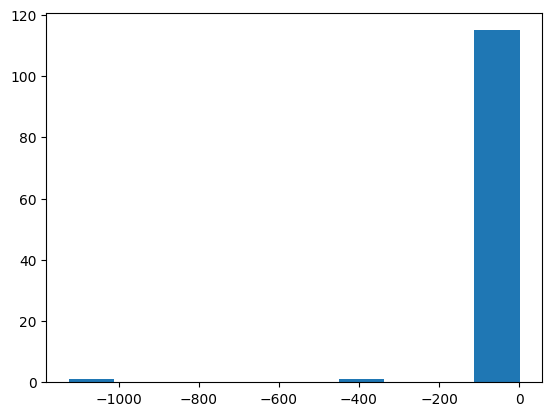

In [35]:
plt.hist(((old_old['K_uf [M]'] - old['K_uf [M]'])/old_old['K_uf [M]']).apply(unc.nominal_value))

(array([ 1.,  0.,  1.,  6.,  5.,  9.,  9., 11., 26., 51.]),
 array([-9.625 , -8.6625, -7.7   , -6.7375, -5.775 , -4.8125, -3.85  ,
        -2.8875, -1.925 , -0.9625,  0.    ]),
 <BarContainer object of 10 artists>)

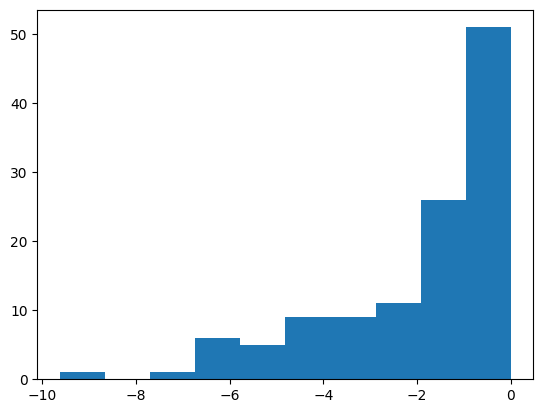

In [38]:
plt.hist(((new['K_uf [M]'] - old['K_uf [M]']) /new['K_uf [M]'] ).apply(unc.nominal_value))

In [20]:
new

,Unnamed: 0,sample,Rg 1 [nm],Rg 2 [nm],charge 1,charge 2,crowder,molar mass [g/mol],crowder wt. [%],T [K],...,theory_a2,theory_a1,Delta_G_elec_theory_[J/mol],Delta_G_depl_theory_[J/mol],r_D_[m3],simple_overlap_volume_[L/M],Delta_G_simple_depl_theory_[J/mol],Delta_G_exp_[J/mol],Delta_G0_exp_[J/mol],mon_conc_[M]
0,58,ssDNA_13bp,2.251666,2.251666,-13,-13,EGly,62.07,0.0,298.15,...,-0.138+/-0.005,1.805+/-0.023,0.0+/-0,0.000000,(1.4060524311488403+/-0)e-09,0.565619,-0.000000,(-5.28+/-0.04)e+04,(-5.28+/-0.04)e+04,0.000000
1,59,ssDNA_13bp,2.251666,2.251666,-13,-13,EGly,62.07,2.5,298.15,...,-0.138+/-0.005,1.805+/-0.023,(3.44+/-0.06)e+03,-575.521669,(1.4336+/-0.0005)e-09,0.565619,-565.550781,(-5.254+/-0.027)e+04,(-5.28+/-0.04)e+04,0.568349
2,60,ssDNA_13bp,2.251666,2.251666,-13,-13,EGly,62.07,5.0,298.15,...,-0.138+/-0.005,1.805+/-0.023,(6.31+/-0.10)e+03,-1175.753238,(1.4573+/-0.0008)e-09,0.565619,-1136.026403,(-5.006+/-0.012)e+04,(-5.28+/-0.04)e+04,1.141646
3,61,ssDNA_13bp,2.251666,2.251666,-13,-13,EGly,62.07,7.5,298.15,...,-0.138+/-0.005,1.805+/-0.023,(8.73+/-0.12)e+03,-1800.711327,(1.4780+/-0.0010)e-09,0.565619,-1711.426867,(-5.204+/-0.028)e+04,(-5.28+/-0.04)e+04,1.719893
4,62,ssDNA_13bp,2.251666,2.251666,-13,-13,EGly,62.07,10.0,298.15,...,-0.138+/-0.005,1.805+/-0.023,(1.081+/-0.014)e+04,-2450.509148,(1.4961+/-0.0012)e-09,0.565619,-2291.752173,(-4.900+/-0.014)e+04,(-5.28+/-0.04)e+04,2.303090
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,261,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG35000,35000.00,15.0,298.15,...,(-4.39+/-0.16)e+04,1622+/-13,(1.419+/-0.016)e+04,-21888.909905,(1.5265+/-0.0014)e-09,923.037483,-10034.262360,(-5.37+/-0.07)e+04,(-5.28+/-0.04)e+04,3.484330
115,262,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG35000,35000.00,20.0,298.15,...,(-4.39+/-0.16)e+04,1622+/-13,(1.682+/-0.017)e+04,-28319.000787,(1.5510+/-0.0016)e-09,923.037483,-13493.039272,(-5.30+/-0.07)e+04,(-5.28+/-0.04)e+04,4.685367
116,263,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG35000,35000.00,25.0,298.15,...,(-4.39+/-0.16)e+04,1622+/-13,(1.893+/-0.017)e+04,-34445.668682,(1.5711+/-0.0016)e-09,923.037483,-17008.827581,(-5.24+/-0.07)e+04,(-5.28+/-0.04)e+04,5.906200
117,264,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG35000,35000.00,30.0,298.15,...,(-4.39+/-0.16)e+04,1622+/-13,(2.065+/-0.016)e+04,-40351.997489,(1.5879+/-0.0016)e-09,923.037483,-20581.627286,(-5.17+/-0.07)e+04,(-5.28+/-0.04)e+04,7.146831


In [17]:
df

,sample,Rg 1 [nm],Rg 2 [nm],charge 1,charge 2,crowder,molar mass [g/mol],crowder wt. [%],T [K],Na conc. [mM],...,theory_a2,theory_a1,Delta_G_elec_theory_[J/mol],Delta_G_depl_theory_[J/mol],r_D_[m3],simple_overlap_volume_[L/M],Delta_G_simple_depl_theory_[J/mol],Delta_G_exp_[J/mol],Delta_G0_exp_[J/mol],mon_conc_[M]
58,ssDNA_13bp,2.251666,2.251666,-13,-13,EGly,62.07,0.0,298.15,35.0,...,-0.138+/-0.005,1.805+/-0.023,0.0+/-0,0.000000,(1.4060524311488403+/-0)e-09,0.565619,-0.000000,(-5.28+/-0.04)e+04,(-5.28+/-0.04)e+04,0.000000
59,ssDNA_13bp,2.251666,2.251666,-13,-13,EGly,62.07,2.5,298.15,35.0,...,-0.138+/-0.005,1.805+/-0.023,(3.44+/-0.06)e+03,-575.521669,(1.4336+/-0.0005)e-09,0.565619,-565.550781,(-5.284+/-0.033)e+04,(-5.28+/-0.04)e+04,0.568349
60,ssDNA_13bp,2.251666,2.251666,-13,-13,EGly,62.07,5.0,298.15,35.0,...,-0.138+/-0.005,1.805+/-0.023,(6.31+/-0.10)e+03,-1175.753238,(1.4573+/-0.0008)e-09,0.565619,-1136.026403,(-5.046+/-0.016)e+04,(-5.28+/-0.04)e+04,1.141646
61,ssDNA_13bp,2.251666,2.251666,-13,-13,EGly,62.07,7.5,298.15,35.0,...,-0.138+/-0.005,1.805+/-0.023,(8.73+/-0.12)e+03,-1800.711327,(1.4780+/-0.0010)e-09,0.565619,-1711.426867,(-5.294+/-0.023)e+04,(-5.28+/-0.04)e+04,1.719893
62,ssDNA_13bp,2.251666,2.251666,-13,-13,EGly,62.07,10.0,298.15,35.0,...,-0.138+/-0.005,1.805+/-0.023,(1.081+/-0.014)e+04,-2450.509148,(1.4961+/-0.0012)e-09,0.565619,-2291.752173,(-4.967+/-0.013)e+04,(-5.28+/-0.04)e+04,2.303090
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG35000,35000.00,15.0,298.15,35.0,...,(-4.39+/-0.16)e+04,1622+/-13,(1.419+/-0.016)e+04,-21888.909905,(1.5265+/-0.0014)e-09,923.037483,-10034.262360,(-5.78+/-0.08)e+04,(-5.28+/-0.04)e+04,3.484330
262,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG35000,35000.00,20.0,298.15,35.0,...,(-4.39+/-0.16)e+04,1622+/-13,(1.682+/-0.017)e+04,-28319.000787,(1.5510+/-0.0016)e-09,923.037483,-13493.039272,(-5.83+/-0.10)e+04,(-5.28+/-0.04)e+04,4.685367
263,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG35000,35000.00,25.0,298.15,35.0,...,(-4.39+/-0.16)e+04,1622+/-13,(1.893+/-0.017)e+04,-34445.668682,(1.5711+/-0.0016)e-09,923.037483,-17008.827581,(-5.72+/-0.06)e+04,(-5.28+/-0.04)e+04,5.906200
264,ssDNA_13bp,2.251666,2.251666,-13,-13,PEG35000,35000.00,30.0,298.15,35.0,...,(-4.39+/-0.16)e+04,1622+/-13,(2.065+/-0.016)e+04,-40351.997489,(1.5879+/-0.0016)e-09,923.037483,-20581.627286,(-5.75+/-0.06)e+04,(-5.28+/-0.04)e+04,7.146831


/tmp/ipykernel_26092/1193365245.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_26092/1193365245.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


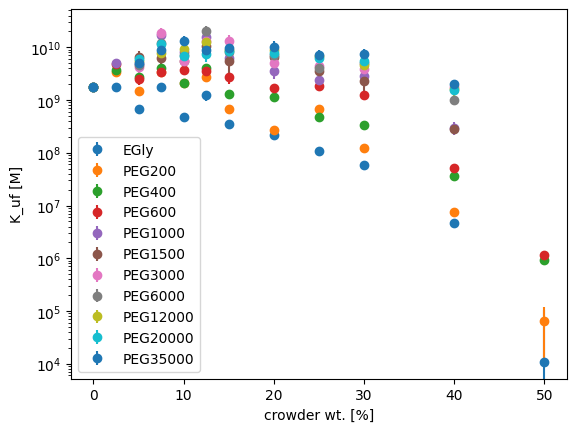

In [7]:
#small = df[(df['crowder'] == 'EGly') | (df['crowder'] == 'PEG200')]

plot_each_peg(df, 'crowder wt. [%]', 'K_uf [M]')
plt.yscale('log')
plt.savefig('old_way.png')

In [9]:
df.columns

Index(['sample', 'Rg 1 [nm]', 'Rg 2 [nm]', 'charge 1', 'charge 2', 'crowder',
       'molar mass [g/mol]', 'crowder wt. [%]', 'T [K]', 'Na conc. [mM]',
       'I [mM]', 'source', 'K_uf [M]', 'density', 'MW_[g/mol]', 'No_mono',
       'Rg_[nm]', 'Rg_err_[nm]', 'Rh_[nm]', 'Rh_err_[nm]', 'V_Rg_[nm3]',
       'V_Rg_err_[nm3]', 'c*_[g/cm3]', 'concentration [M]', 'c*_[M]', 'c/c*',
       'a2_exp', 'a1_exp', 'a0_exp', 'chi2', 'chi2_red', 'R2', 'n Beta [1/M]',
       'theory_a2', 'theory_a1', 'Delta_G_elec_theory_[J/mol]',
       'Delta_G_depl_theory_[J/mol]', 'r_D_[m3]',
       'simple_overlap_volume_[L/M]', 'Delta_G_simple_depl_theory_[J/mol]',
       'Delta_G_exp_[J/mol]', 'Delta_G0_exp_[J/mol]', 'mon_conc_[M]'],
      dtype='object')

In [10]:
df.groupby('crowder wt. [%]')['mon_conc_[M]'].std()

crowder wt. [%]
0.0     0.000000e+00
2.5     1.110223e-16
5.0     2.106500e-16
7.5     1.857758e-16
10.0    4.213000e-16
12.5    0.000000e+00
15.0    3.715517e-16
20.0    8.426000e-16
25.0    0.000000e+00
30.0    7.431034e-16
40.0    1.685200e-15
50.0    0.000000e+00
Name: mon_conc_[M], dtype: float64

/tmp/ipykernel_58274/1193365245.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_58274/1193365245.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


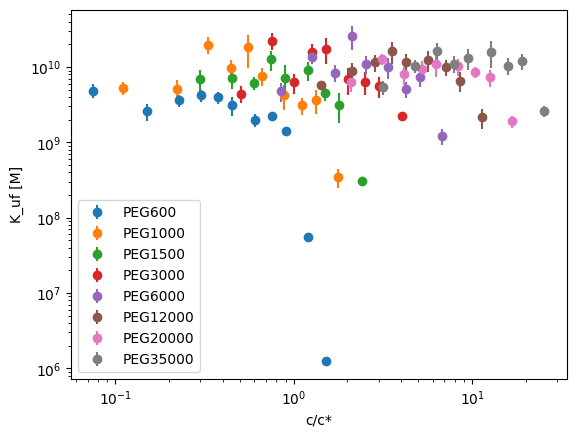

In [16]:
#plt.figure(figsize=(10,10))
plot_each_peg(df, 'c/c*', 'K_uf [M]')
plt.yscale('log')
plt.xscale('log')

In [12]:
df.columns

Index(['sample', 'Rg 1 [nm]', 'Rg 2 [nm]', 'charge 1', 'charge 2', 'crowder',
       'molar mass [g/mol]', 'crowder wt. [%]', 'T [K]', 'Na conc. [mM]',
       'I [mM]', 'source', 'K_uf [M]', 'density', 'MW_[g/mol]', 'No_mono',
       'Rg_[nm]', 'Rg_err_[nm]', 'Rh_[nm]', 'Rh_err_[nm]', 'V_Rg_[nm3]',
       'V_Rg_err_[nm3]', 'c*_[g/cm3]', 'concentration [M]', 'c*_[M]', 'c/c*',
       'a2_exp', 'a1_exp', 'a0_exp', 'chi2', 'chi2_red', 'R2', 'n Beta [1/M]',
       'theory_a2', 'theory_a1', 'Delta_G_elec_theory_[J/mol]',
       'Delta_G_depl_theory_[J/mol]', 'r_D_[m3]',
       'simple_overlap_volume_[L/M]', 'Delta_G_simple_depl_theory_[J/mol]',
       'Delta_G_exp_[J/mol]', 'Delta_G0_exp_[J/mol]', 'mon_conc_[M]'],
      dtype='object')

In [10]:
df['Rg_[nm]'].unique()

array([0.89557227, 1.20625315, 1.52791665, 2.28875946, 3.42847225,
       5.1357175 , 6.91733721, 9.58583898])

In [12]:
df['c*_[M]'].unique()

array([5.51897684e-01, 2.25863008e-01, 1.11137723e-01, 3.30643534e-02,
       9.83690714e-03, 2.92655782e-03, 1.19768786e-03, 4.50059672e-04])

In [14]:
df['concentration [M]'].unique()

array([0.        , 0.04166667, 0.08333333, 0.125     , 0.16666667,
       0.20833333, 0.25      , 0.33333333, 0.41666667, 0.5       ,
       0.66666667, 0.83333333, 0.025     , 0.05      , 0.075     ,
       0.1       , 0.15      , 0.2       , 0.3       , 0.4       ,
       0.03333333, 0.06666667, 0.13333333, 0.26666667, 0.01666667,
       0.00833333, 0.0125    , 0.02083333, 0.00416667, 0.00625   ,
       0.01041667, 0.0025    , 0.00375   , 0.005     , 0.0075    ,
       0.01      , 0.015     , 0.02      , 0.00142857, 0.00214286,
       0.00285714, 0.00357143, 0.00428571, 0.00571429, 0.00714286,
       0.00857143, 0.01142857])

In [13]:
df['n Beta [1/M]']

58     0.291+/-0.005
59     0.291+/-0.005
60     0.291+/-0.005
61     0.291+/-0.005
62     0.291+/-0.005
           ...      
259      164.1+/-3.0
260      164.1+/-3.0
261      164.1+/-3.0
262      164.1+/-3.0
263      164.1+/-3.0
Name: n Beta [1/M], Length: 117, dtype: object

In [21]:
df.columns

Index(['sample', 'Rg 1 [nm]', 'Rg 2 [nm]', 'charge 1', 'charge 2', 'crowder',
       'molar mass [g/mol]', 'crowder wt. [%]', 'T [K]', 'Na conc. [mM]',
       'I [mM]', 'source', 'K_uf [M]', 'density', 'MW_[g/mol]', 'No_mono',
       'Rg_[nm]', 'Rg_err_[nm]', 'Rh_[nm]', 'Rh_err_[nm]', 'V_Rg_[nm3]',
       'V_Rg_err_[nm3]', 'c*_[g/cm3]', 'concentration [M]', 'c*_[M]', 'c/c*',
       'a2_exp', 'a1_exp', 'a0_exp', 'chi2', 'chi2_red', 'R2', 'n Beta [1/M]',
       'theory_a2', 'theory_a1', 'Delta_G_elec_theory_[J/mol]',
       'Delta_G_depl_theory_[J/mol]', 'r_D_[m3]',
       'simple_overlap_volume_[L/M]', 'Delta_G_simple_depl_theory_[J/mol]',
       'Delta_G_exp_[J/mol]', 'Delta_G0_exp_[J/mol]', 'mon_conc_[M]'],
      dtype='object')

In [20]:
df = df[['sample', 'crowder', 'Na conc. [mM]', 'concentration [M]', 'I [mM]','n Beta [1/M]', 'Delta_G_exp_[J/mol]', 
         'Delta_G_simple_depl_theory_[J/mol]', 'mon_conc_[M]']]

In [21]:
df

,sample,crowder,Na conc. [mM],concentration [M],I [mM],n Beta [1/M],Delta_G_exp_[J/mol],Delta_G_simple_depl_theory_[J/mol],mon_conc_[M]
58,ssDNA_13bp,EGly,35.0,0.000000,48.3,0.291+/-0.005,(-5.28+/-0.04)e+04,-0.000000,0.000000
59,ssDNA_13bp,EGly,35.0,0.402771,48.3,0.291+/-0.005,(-5.284+/-0.033)e+04,-564.743057,0.567537
60,ssDNA_13bp,EGly,35.0,0.805542,48.3,0.291+/-0.005,(-5.046+/-0.016)e+04,-1129.486114,1.135074
61,ssDNA_13bp,EGly,35.0,1.208313,48.3,0.291+/-0.005,(-5.294+/-0.023)e+04,-1694.229171,1.702611
62,ssDNA_13bp,EGly,35.0,1.611084,48.3,0.291+/-0.005,(-4.967+/-0.013)e+04,-2258.972227,2.270148
...,...,...,...,...,...,...,...,...,...
259,ssDNA_13bp,PEG35000,35.0,0.004286,48.3,164.1+/-3.0,(-5.78+/-0.08)e+04,-9806.443957,3.405221
260,ssDNA_13bp,PEG35000,35.0,0.005714,48.3,164.1+/-3.0,(-5.83+/-0.10)e+04,-13075.258609,4.540295
261,ssDNA_13bp,PEG35000,35.0,0.007143,48.3,164.1+/-3.0,(-5.72+/-0.06)e+04,-16344.073261,5.675369
262,ssDNA_13bp,PEG35000,35.0,0.008571,48.3,164.1+/-3.0,(-5.75+/-0.06)e+04,-19612.887914,6.810443


In [16]:
df.to_csv('helping_files/ionic_strength_dependence/crowders_data.csv')

In [17]:
df['mono']

,wt_%,D_Na_[um2/s],D_Na_err_[um2/s],D_crowder_[um2/s],D_crowder_err_[um2/s],crowder,D_Na_uf_[um2/s],D_crowder_uf_[um2/s],MW_[g/mol],No_mono,...,density,mass concentration [g/cm3],concentration [M],monomers concentration [M],ksi,D_Na_[um2/s] corr,n Beta [1/M],chi2,redchi2,R^2
0,1.0,1365.0760,37.30372,30.83452,0.055466,PEG35000,(1.37+/-0.04)e+03,30.83+/-0.06,35000.0,794.143,...,0.998744,0.009987,0.000285,0.226613,13.490967,1416.671547,143+/-9,9.525206,1.190651,0.921228
1,1.5,1404.5150,45.17060,26.34168,0.040308,PEG35000,(1.40+/-0.05)e+03,26.34+/-0.04,35000.0,794.143,...,0.999616,0.014994,0.000428,0.340216,9.946959,1412.380653,143+/-9,9.525206,1.190651,0.921228
2,3.0,1237.3990,35.69728,18.37717,0.025882,PEG35000,(1.24+/-0.04)e+03,18.377+/-0.026,35000.0,794.143,...,1.002232,0.030067,0.000859,0.682214,5.902915,1399.778853,143+/-9,9.525206,1.190651,0.921228
3,4.5,1289.8420,62.48437,13.03956,0.061334,PEG35000,(1.29+/-0.06)e+03,13.04+/-0.06,35000.0,794.143,...,1.004848,0.045218,0.001292,1.025991,4.346593,1387.436659,143+/-9,9.525206,1.190651,0.921228
4,6.0,1126.2400,58.74440,10.01745,0.025307,PEG35000,(1.13+/-0.06)e+03,10.017+/-0.025,35000.0,794.143,...,1.007465,0.060448,0.001727,1.371550,3.496214,1375.275703,143+/-9,9.525206,1.190651,0.921228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,7.5,1059.3110,56.60522,146.77290,0.459099,PEG1500,(1.06+/-0.06)e+03,146.8+/-0.5,1500.0,33.643,...,1.010081,0.075756,0.050504,1.699107,2.760586,1359.115805,5.9+/-0.6,4.816534,0.688076,0.953227
85,10.0,1031.9890,160.91470,132.50240,0.334128,PEG1500,(1.03+/-0.16)e+03,132.50+/-0.33,1500.0,33.643,...,1.014441,0.101444,0.067629,2.275256,2.217656,1338.084111,5.9+/-0.6,4.816534,0.688076,0.953227
86,12.5,920.6009,104.00470,113.96290,0.233071,PEG1500,(9.2+/-1.0)e+02,113.96+/-0.23,1500.0,33.643,...,1.018801,0.127350,0.084900,2.856294,1.869884,1317.375825,5.9+/-0.6,4.816534,0.688076,0.953227
87,15.0,831.2803,58.79731,104.98180,0.135397,PEG1500,(8.3+/-0.6)e+02,104.98+/-0.14,1500.0,33.643,...,1.023162,0.153474,0.102316,3.442222,1.625690,1296.953657,5.9+/-0.6,4.816534,0.688076,0.953227


In [16]:
PEG35K = df[df['crowder'] == 'PEG35000']

In [20]:
PEG35K.columns

Index(['sample', 'Rg 1 [nm]', 'Rg 2 [nm]', 'charge 1', 'charge 2', 'crowder',
       'molar mass [g/mol]', 'crowder wt. [%]', 'T [K]', 'Na conc. [mM]',
       'I [mM]', 'source', 'K_uf [M]', 'density', 'MW_[g/mol]', 'No_mono',
       'Rg_[nm]', 'Rg_err_[nm]', 'Rh_[nm]', 'Rh_err_[nm]', 'V_Rg_[nm3]',
       'V_Rg_err_[nm3]', 'c*_[g/cm3]', 'concentration [M]', 'c*_[M]', 'c/c*',
       'a2_exp', 'a1_exp', 'a0_exp', 'chi2', 'chi2_red', 'R2', 'n Beta [1/M]',
       'theory_a2', 'theory_a1', 'Delta_G_elec_theory_[J/mol]',
       'Delta_G_depl_theory_[J/mol]', 'r_D_[m3]',
       'simple_overlap_volume_[L/M]', 'Delta_G_simple_depl_theory_[J/mol]',
       'Delta_G_exp_[J/mol]', 'Delta_G0_exp_[J/mol]', 'mon_conc_[M]'],
      dtype='object')

In [17]:
PEG35K['mass concentration [g/cm3]']

KeyError: 'mass concentration [g/cm3]'

In [ ]:
theoretical_potential = pd.read_csv('helping_files/ionic_strength_dependence/ionic_impact.csv', index_col=0)

def model(x, A, B, k):

    return A + B * np.exp(-k * x)



theoretical_potential

# Checking the dependency on full Debye potential 

In [ ]:


for crowder in df['crowder'].unique():

    dat_temp = df[df['crowder'] == crowder]

    theory =  dat_temp['Delta_G_elec_theory_[J/mol]'] + dat_temp['Delta_G_depl_theory_[J/mol]'] 
    
    theory, _ = uts.get_float_uncertainty(theory)

    exp = dat_temp['Delta_G_exp_[J/mol]'] - dat_temp['Delta_G0_exp_[J/mol]']

    exp, _ = uts.get_float_uncertainty(exp)
    
    plt.plot(dat_temp['crowder wt. [%]'], theory/1000, '.', label=f'{crowder}')
    

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

In [ ]:
with plt.style.context(['science']):
    fig, axs = plt.subplots(3, 2, figsize=(10, 10))

    for crowder in df['crowder'].unique():
    
        dat_temp = df[df['crowder'] == crowder]

        
        theory =  dat_temp['Delta_G_elec_theory_[J/mol]'] + dat_temp['Delta_G_simple_depl_theory_[J/mol]'] 
        theory, _ = uts.get_float_uncertainty(theory)
        axs[0,0].plot(dat_temp['crowder wt. [%]'], theory/1000, '.', label=f'{crowder}')
        axs[0,0].set_ylabel(r'$\Delta \Delta G_{\text{elec}} + \Delta G_{\text{depl}}$ [kJ/mol]')
        axs[0,0].set_xlabel(r'crowder wt. [\%]')

        
        exp = dat_temp['Delta_G_exp_[J/mol]'] - dat_temp['Delta_G0_exp_[J/mol]']
    
        exp, _ = uts.get_float_uncertainty(exp)
        
        axs[0,1].plot(dat_temp['crowder wt. [%]'], exp/1000, '.', label=f'{crowder}')
        axs[0,1].set_xlabel(r'crowder wt. [\%]')
        axs[0,1].set_ylabel(r'$\Delta G_{\mathrm{exp}} - \Delta G^{0}_{\mathrm{exp}}$ [kJ/mol]')

        rD, _ = uts.get_float_uncertainty(dat_temp['r_D_[m3]'])
        
        axs[1,0].plot(dat_temp['crowder wt. [%]'],rD * 10 **9, '.', label=f'{crowder}')
        axs[1,0].set_xlabel(r'crowder wt. [\%]')
        axs[1,0].set_ylabel(r'$r_D$ [nm]')
        
        elec,_ = uts.get_float_uncertainty(dat_temp['Delta_G_elec_theory_[J/mol]'])

        axs[1,1].plot(dat_temp['crowder wt. [%]'], elec/1000, '.', label=f'{crowder}')
        axs[1,1].set_ylabel(r'$\Delta \Delta G_{\text{elec}}$ [kJ/mol]')
        axs[1,1].set_xlabel(r'crowder wt. [\%]')
        
        depl= dat_temp['Delta_G_simple_depl_theory_[J/mol]']
        axs[2,1].plot(dat_temp['crowder wt. [%]'], depl/1000, '.', label=f'{crowder}')
        axs[2,1].set_xlabel(r'crowder wt. [\%]')
        axs[2,1].set_ylabel(r'$\Delta G_{\text{depl}}$ [kJ/mol]')

    volume = df.groupby(by='crowder')['simple_overlap_volume_[L/M]'].mean()/(10 ** (-24) * 6.02214076e23)

    molarr_mass = df.groupby(by='crowder')['MW_[g/mol]'].mean()
    axs[2,0].plot(molarr_mass, volume, '.', label=f'{crowder}')
    axs[2,0].set_xlabel('PEG molar mas [g/mol]')
    axs[2,0].set_ylabel(r'$V_{\mathrm{depl}}$ [nm$^3$]')
    
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.savefig('calculations_results.pdf', dpi=600)

In [ ]:
wrong

In [ ]:
wrong = uts.get_float_uncertainty(df['n Beta [1/M]'] * df['concentration [M]'])

In [ ]:
dat.columns

### Theory and experiments

In [8]:
df.columns

Index(['sample', 'Rg 1 [nm]', 'Rg 2 [nm]', 'charge 1', 'charge 2', 'crowder',
       'molar mass [g/mol]', 'crowder wt. [%]', 'T [K]', 'Na conc. [mM]',
       'I [mM]', 'source', 'K_uf [M]', 'density', 'MW_[g/mol]', 'No_mono',
       'Rg_[nm]', 'Rg_err_[nm]', 'Rh_[nm]', 'Rh_err_[nm]', 'V_Rg_[nm3]',
       'V_Rg_err_[nm3]', 'c*_[g/cm3]', 'concentration [M]', 'c*_[M]', 'c/c*',
       'a2_exp', 'a1_exp', 'a0_exp', 'chi2', 'chi2_red', 'R2', 'n Beta [1/M]',
       'theory_a2', 'theory_a1', 'Delta_G_elec_theory_[J/mol]',
       'Delta_G_depl_theory_[J/mol]', 'r_D_[m3]',
       'simple_overlap_volume_[L/M]', 'Delta_G_simple_depl_theory_[J/mol]',
       'Delta_G_exp_[J/mol]', 'Delta_G0_exp_[J/mol]', 'mon_conc_[M]'],
      dtype='object')

In [18]:
def group_take_first(df, grouping_cols, value_cols):
    return (
        df.groupby(grouping_cols, as_index=False)[value_cols]
          .first()
    )


plot_df = group_take_first(
    dat,
    grouping_cols=['source', 'sample', 'crowder'],
    value_cols=['theory_a1', 'theory_a2', 'a1_exp', 'molar mass [g/mol]','a2_exp', 'No_mono', 'n Beta [1/M]','Rg_[nm]']
)

Text(0, 0.5, '$R_g$ [nm]')

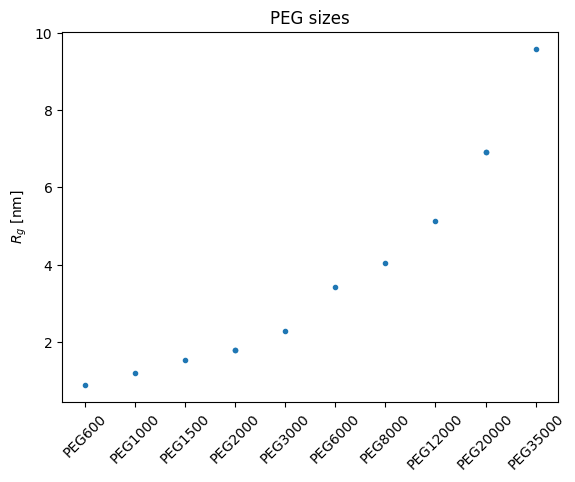

In [21]:
plot_df.sort_values(by=['molar mass [g/mol]', 'No_mono'], inplace=True)
plt.plot(plot_df['crowder'], plot_df['Rg_[nm]'], '.')
plt.xticks(rotation=45)
plt.title('PEG sizes')
plt.ylabel(r'$R_g$ [nm]')

In [51]:
-plot_df['a2_exp']

0       (1.0+/-0.5)e+02
1               18+/-30
2       (4.6+/-2.3)e+03
3       (7.5+/-1.8)e+03
4               57+/-12
5       (7.4+/-0.8)e+03
6              134+/-10
7     (1.82+/-0.31)e+04
8       (4.2+/-1.0)e+02
9       (6.3+/-0.7)e+04
10           22.4+/-1.2
11      (1.9+/-0.4)e+03
Name: a2_exp, dtype: object

In [52]:
plot_df['sqrt(-a2)'] = (-plot_df['a2_exp'])**(0.5)

/tmp/ipykernel_39790/1193365245.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_39790/1193365245.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


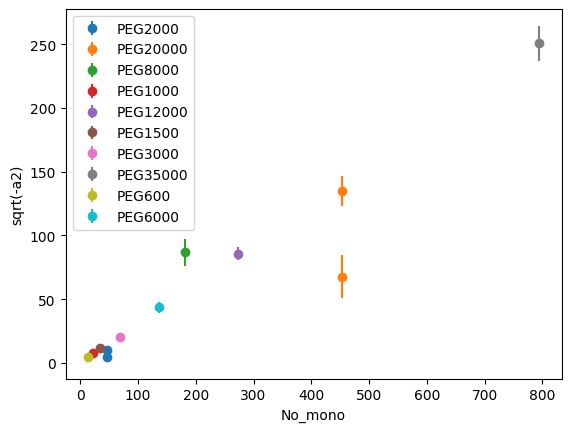

In [53]:
plot_each_peg(plot_df, 'No_mono', 'sqrt(-a2)')
# plt.xscale('log')
# plt.yscale('log')

In [ ]:
plot_each_peg(plot_df, 'No_mono', 'n Beta [1/M]')
plt.plot(plot_df['No_mono'], 0.15*plot_df['No_mono'])
# plt.xscale('log')
# plt.yscale('log')

/tmp/ipykernel_39790/1193365245.py:10: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if x.dtype == unc.core.AffineScalarFunc:
/tmp/ipykernel_39790/1193365245.py:13: DeprecationWarning: in the future the `.dtype` attribute of a given datatype object must be a valid dtype instance. `data_type.dtype` may need to be coerced using `np.dtype(data_type.dtype)`. (Deprecated NumPy 1.20)
  if y.dtype == unc.core.AffineScalarFunc:


In [48]:
plot_df.columns

Index(['source', 'sample', 'crowder', 'theory_a1', 'theory_a2', 'a1_exp',
       'a2_exp', 'sqrt(-a2)'],
      dtype='object')

In [ ]:
Index(['sample', 'Rg 1 [nm]', 'Rg 2 [nm]', 'charge 1', 'charge 2', 'crowder',
       'molar mass [g/mol]', 'crowder wt. [%]', 'T [K]', 'Na conc. [mM]',
       'I [mM]', 'source', 'K_uf [M]', 'density', 'MW_[g/mol]', 'No_mono',
       'Rg_[nm]', 'Rg_err_[nm]', 'Rh_[nm]', 'Rh_err_[nm]', 'V_Rg_[nm3]',
       'V_Rg_err_[nm3]', 'c*_[g/cm3]', 'concentration [M]', 'c*_[M]', 'c/c*',
       'a2_exp', 'a1_exp', 'a0_exp', 'chi2', 'chi2_red', 'R2', 'n Beta [1/M]',
       'theory_a2', 'theory_a1', 'Delta_G_elec_theory_[J/mol]',
       'Delta_G_depl_theory_[J/mol]', 'Delta_G_exp_[J/mol]',
       'Delta_G0_exp_[J/mol]']

In [ ]:
df['concentration [M]'].median()

In [ ]:
a1_theory, _ = uts.get_float_uncertainty(plot_df['theory_a1'])
a2_theory, _ = uts.get_float_uncertainty(plot_df['theory_a2'])


a1_exp, a1_exp_err = uts.get_float_uncertainty(plot_df['a1_exp'])
a2_exp, a2_exp_err = uts.get_float_uncertainty(plot_df['a2_exp'])

with plt.style.context(['science']):
    fig, axs = plt.subplots(1, 3, figsize=(10, 3.5))

    geom_fact = np.linalg.lstsq(a1_theory[:, np.newaxis], a1_exp, rcond=None)[0][0]
    
    axs[0].errorbar(a1_theory, a1_exp / geom_fact, yerr=a1_exp_err/geom_fact, fmt='v')
    axs[0].set_xlabel('equation')
    axs[0].set_ylabel(r'$a_1/g_{\text{fact}}$')
    axs[0].set_title(r'parameter $a_1$')
    x1 = np.linspace(min(a1_theory), max(a1_theory))
    axs[0].plot(x1, x1)
    axs[0].text(0.05, 0.95, rf'$g_{{\rm fact}} = {geom_fact:.3f}$', 
                transform=axs[0].transAxes, verticalalignment='top', fontsize=12)
    axs[0].set_xscale('log')
    axs[0].set_yscale('log')
    
    

    axs[1].plot(-a2_theory, -a2_exp, 'v')
    axs[1].set_xlabel('equation')
    axs[1].set_ylabel(r'$-a_2$')
    axs[1].set_title(r'parameter $a_2$')
    axs[1].set_xscale('log')
    axs[1].set_yscale('log')
    x = np.linspace(min(-a2_theory), max(-a2_theory))
    axs[1].plot(x, x)

    delta_G0, _ = uts.get_float_uncertainty(df['Delta_G0_exp_[J/mol]'])
    delta_G_elec, _ = uts.get_float_uncertainty(df['Delta_G_elec_theory_[J/mol]']) 
    calculated_G =  delta_G_elec + df['Delta_G_simple_depl_theory_[J/mol]'] + delta_G0 
    experimental_G, _ = uts.get_float_uncertainty(df['Delta_G_exp_[J/mol]'])
    #experimental_G -= delta_G0
    
    axs[2].scatter(
        experimental_G,
        calculated_G,
        alpha=0.5
    )
    
    lims = [
        min(experimental_G.min(), calculated_G.min()),
        max(experimental_G.max(), calculated_G.max())
    ]
    
    axs[2].plot(lims, lims, '--') 
    axs[2].set_xlim(lims)
    axs[2].set_ylim(lims)
    
    axs[2].set_xlabel('Experimental')
    axs[2].set_ylabel('Calculated')
    axs[2].set_aspect('equal', adjustable='box')
    axs[2].set_title(r'$\Delta G$ comparison')
    

    fig.text(0.05, 0.95, 'a)', fontsize=12, fontweight='bold', ha='center', va='center')
    fig.text(0.40, 0.95, 'b)', fontsize=12, fontweight='bold', ha='center', va='center')
    fig.text(0.75, 0.95, 'c)', fontsize=12, fontweight='bold', ha='center', va='center')

    
    plt.tight_layout()

In [ ]:
df.columns # 'Delta_G_simple_depl_theory_[J/mol]' 'Delta_G_depl_theory_[J/mol]'

In [ ]:
df['crowder'].unique()

In [ ]:
df

In [ ]:
df.sort_values(by=['molar mass [g/mol]', 'crowder wt. [%]'], inplace=True)
simple = df['Delta_G_simple_depl_theory_[J/mol]']
full = df['Delta_G_depl_theory_[J/mol]']

plt.plot(np.arange(len(simple)), simple, '.')

In [ ]:
elec, _ = uts.get_float_uncertainty(df['Delta_G_elec_theory_[J/mol]'])
plt.plot(np.arange(len(elec)), elec, '.')

In [ ]:
exp, _ = uts.get_float_uncertainty(df['Delta_G_exp_[J/mol]'])
K = 
plt.plot(df['concentration [M]'][13:24], exp[13:24], '.')

In [ ]:
plt.plot(np.arange(len(elec)), full - simple, '.')

In [ ]:
plt.plot(np.arange(len(elec)), elec + simple, '.')

In [ ]:
a1_exp/a1_theory

In [ ]:
x = np.linspace(0,1)

y = np.sqrt(1/(x + 1) + 5)

plt.plot(x, y + 0.2*x)

In [ ]:
print(np.min(-a2_theory), np.max(-a2_theory))

In [ ]:
print(len(a2_theory), len(a2_exp))

Estimating values from the PNAS paper

In [ ]:
x

In [ ]:
def plot_fit(probe):

    x = np.array(PNAS.get_probe(probe)['c [M]'], dtype=np.float64)
    #y, y_error = PNAS.get_float_uncertainty(unp.log(PNAS.get_probe(probe)['K [M]']))

    y, y_error = PNAS.get_float_uncertainty(1/PNAS.get_probe(probe)['K [M]'])

    

    with plt.style.context(['science']):

        plt.plot(x,y, '.')
    

In [ ]:
plot_fit('Triethylene glycol')

In [ ]:
plot_fit('PEG 6000')

In [ ]:
coeff = PNAS.coeff

In [ ]:
coeff

In [ ]:
import utils as uts
import sodium_crowder_equilibrium_constant as scec



data =  scec.calc_sodium_crowder_eq_constant()

df_ficoll = data[data['crowder'].str.contains('Ficoll', case=False)]
df_peg = data[data['crowder'].str.contains('PEG', case=False)]
df_dextran = data[data['crowder'].str.contains('Dextran', case=False)]



In [ ]:
def choose_crowder(name):
    dat = data[data['crowder'] == name]

    return dat

In [ ]:
eg = choose_crowder('PEG200')

In [ ]:
eg

In [ ]:
def microviscosity(df):
    a, b = 0.7, 1.45
    return np.exp(b * (0.17 / df['ksi']) ** a)
    

In [ ]:
plt.plot((1425 - microviscosity(eg)*uts.get_float_uncertainty(eg['D_Na_[um2/s]'])[0])/1425 * 100, '.')

In [ ]:
plt.hist(uts.get_float_uncertainty(eg['D_Na_[um2/s]'])[1]/uts.get_float_uncertainty(eg['D_Na_[um2/s]'])[0]*100)

In [ ]:
plt.hist(df_dextran['K complex'].apply(lambda x: x.nominal_value))

In [ ]:
plt.hist(df_dextran['slope'].apply(lambda x: x.nominal_value))

In [ ]:
plt.hist(df_peg['slope'].apply(lambda x: x.nominal_value), bins=20)

In [ ]:
plt.hist(df_peg['K complex'].apply(lambda x: x.nominal_value))

In [ ]:
plt.hist(df_ficoll['K complex'].apply(lambda x: x.nominal_value))

In [ ]:
plt.hist(df_ficoll['slope'].apply(lambda x: x.nominal_value))

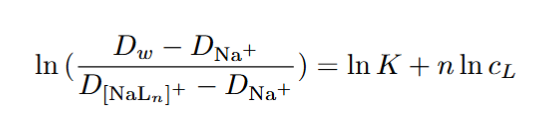

In [ ]:
1/0.6

In [ ]:
merged_df

In [ ]:
data

In [ ]:
data.columns

In [ ]:
Na0 = data[data['wt_%'] == 0]['D_Na_[um2/s]'].mean()

In [ ]:
Na0

In [ ]:
plt.hist(data['monomers concentration [M]'], bins=30)

In [ ]:
# Constants
A = 1400  # Example value for A
B = 1100  # Example value for B

# Original function
def original_function(x):
    return (A + B * x)/ (1 + x)



def taylor_series_half(x):
      # Centered around x = 1/2
    constant = (1/3) * (2 * A + B)
    linear = -(4/9) * (x - 0.5) * (A - B)
    # Include the first two terms; higher-order terms are denoted by O(h^2)
    return constant + linear


def taylor_series_zero(x):
        
    # Expanded around 0
    return A + (B - A) * x

def taylor_series_one(x):
    #Expanded around 1
    return 1/2 * (A + B) + 1/4 * (x - 1) * (B - A)    
    


# Generate x values for the plot
x = np.linspace(0, 4, 500)

# Evaluate functions
y_original = original_function(x)
y_taylor_half = taylor_series_half(x)
y_taylor_0 = taylor_series_zero(x)
y_taylor_one = taylor_series_one(x)

# Plotting
plt.figure(figsize=(10, 6))

plt.plot(x, (y_original - y_taylor_half)/y_original, '--', label="arund 1/2")
plt.plot(x, (y_original - y_taylor_0)/y_original, label="around  0")
plt.plot(x, (y_original - y_taylor_one)/y_original, label="around  1")

plt.xlabel("x")
plt.ylabel("f(x)/expansion")
plt.title("Comparison of Original Function and Taylor Expansion")
plt.legend()